<a href="https://colab.research.google.com/github/trazhboi/Stock-Predicton/blob/main/StockM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import yfinance as yf

In [103]:
sp500 = yf.Ticker("^GSPC")

In [104]:
sp500 = sp500.history(period="max")

In [105]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-06 00:00:00-05:00,6816.740234,6944.890137,6816.740234,6932.299805,6283680000,0.0,0.0
2026-02-09 00:00:00-05:00,6917.259766,6980.100098,6905.870117,6964.819824,5650260000,0.0,0.0
2026-02-10 00:00:00-05:00,6974.490234,6986.830078,6937.529785,6941.810059,5595950000,0.0,0.0


In [106]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-01-30 00:00:00-05:00', '2026-02-02 00:00:00-05:00',
               '2026-02-03 00:00:00-05:00', '2026-02-04 00:00:00-05:00',
               '2026-02-05 00:00:00-05:00', '2026-02-06 00:00:00-05:00',
               '2026-02-09 00:00:00-05:00', '2026-02-10 00:00:00-05:00',
               '2026-02-11 00:00:00-05:00', '2026-02-12 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24646, freq=None)

<Axes: xlabel='Date'>

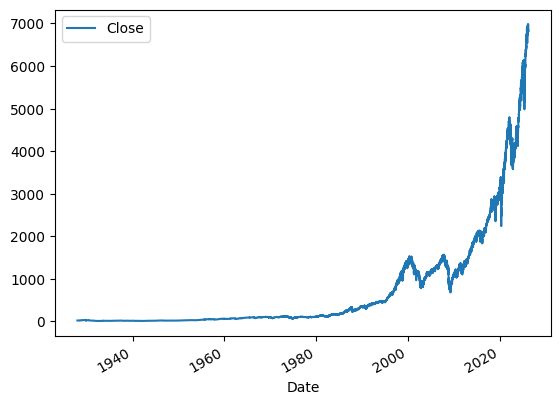

In [107]:
sp500.plot.line(y="Close", use_index=True)

In [108]:
sp500 = sp500.drop(columns=["Dividends", "Stock Splits"], errors='ignore')

In [109]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [110]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-02-06 00:00:00-05:00,6816.740234,6944.890137,6816.740234,6932.299805,6283680000,6964.819824
2026-02-09 00:00:00-05:00,6917.259766,6980.100098,6905.870117,6964.819824,5650260000,6941.810059
2026-02-10 00:00:00-05:00,6974.490234,6986.830078,6937.529785,6941.810059,5595950000,6941.470215


In [111]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [112]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-02-06 00:00:00-05:00,6816.740234,6944.890137,6816.740234,6932.299805,6283680000,6964.819824,1
2026-02-09 00:00:00-05:00,6917.259766,6980.100098,6905.870117,6964.819824,5650260000,6941.810059,0
2026-02-10 00:00:00-05:00,6974.490234,6986.830078,6937.529785,6941.810059,5595950000,6941.470215,0


In [113]:
sp500 = sp500.loc["1990-01-01":].copy()

In [114]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-02-06 00:00:00-05:00,6816.740234,6944.890137,6816.740234,6932.299805,6283680000,6964.819824,1
2026-02-09 00:00:00-05:00,6917.259766,6980.100098,6905.870117,6964.819824,5650260000,6941.810059,0
2026-02-10 00:00:00-05:00,6974.490234,6986.830078,6937.529785,6941.810059,5595950000,6941.470215,0


In [115]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train=sp500.iloc[:-100]
test=sp500.iloc[-100:]

predictors  = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [116]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])


In [117]:
import pandas as pd
preds = pd.Series(preds, index=test.index)

In [118]:
precision_score(test["Target"], preds)

0.5729166666666666

In [119]:
combined=pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

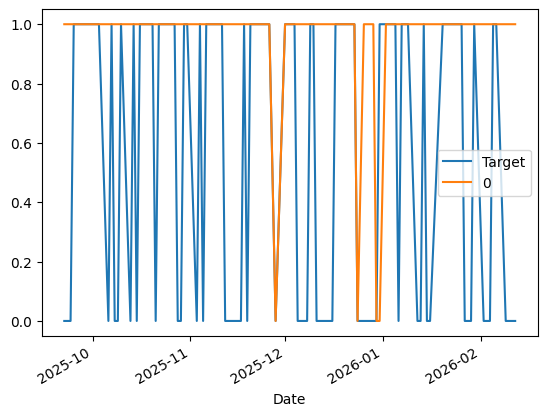

In [120]:
combined.plot()

In [121]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds=model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions") # Assign name to the Series
    combined=pd.concat([test["Target"], preds], axis=1)
    return combined

In [122]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions=[]

    for i in range(start, data.shape[0], step):
      train = data.iloc[0:i].copy()

      test = data.iloc[i:(i+step)].copy()
      predictions = predict(train, test, predictors, model)
      all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [133]:
predictions= backtest(sp500, model, predictors)

In [134]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,4727
1.0,868


In [125]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5307116104868914

In [126]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.537295
0,0.462705


In [127]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
  rolling_averages = sp500.rolling(horizon).mean()

  ratio_column = f"Close_Ratio_{horizon}"
  sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

  trend_column = f"Trend_{horizon}"
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

  new_predictors += [ratio_column, trend_column]

In [128]:
sp500 = sp500.dropna()

In [129]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-05 00:00:00-05:00,6837.390137,6857.850098,6780.129883,6798.399902,6989120000,6932.299805,1,0.993837,0.0,0.984864,1.0,0.992148,33.0,1.078012,142.0,1.342293,533.0
2026-02-06 00:00:00-05:00,6816.740234,6944.890137,6816.740234,6932.299805,6283680000,6964.819824,1,1.009752,1.0,1.004458,2.0,1.011443,33.0,1.098612,143.0,1.368075,534.0
2026-02-09 00:00:00-05:00,6917.259766,6980.100098,6905.870117,6964.819824,5650260000,6941.810059,0,1.002340,2.0,1.009510,2.0,1.015896,33.0,1.103138,143.0,1.373802,535.0


In [130]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [131]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds=model.predict_proba(test[predictors])[:,1]
    preds[preds>=.6] = 1
    preds[preds<.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions") # Assign name to the Series
    combined=pd.concat([test["Target"], preds], axis=1)
    return combined

In [101]:
predictions = backtest(sp500,model, new_predictors)

In [135]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,4727
1.0,868


In [136]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5414746543778802